# 04. Prior & Universe 설계 비교 분석

## 목적
보류 중인 두 가지 설계 결정에 대해 데이터 기반 판단 근거를 제공한다.

1. **Prior 비교**: `w_mkt = 시가총액 비중` vs `w_mkt = 1/N (균등)`
2. **build_P 가중치 비교**: `mcap 비중` vs `1/vol (변동성 역수)`

## 유니버스 (확정 — 별도 분석 불필요)
[01_DataCollection.ipynb](01_DataCollection.ipynb)에서 이미 **point-in-time S&P500 멤버십 필터**가 적용되어 look-ahead bias가 없다. 본 노트북에서 추가로 "전 기간 X% 커버" 같은 사후 필터를 도입하면 미래 정보(2025년까지의 생존 여부)가 유입되므로, **패널을 그대로 사용**한다 (raw, point-in-time).

## 설계 기준
| 파라미터 | 값 |
|---------|----|
| `TRAIN_WINDOW` | 60 (월) |
| `TAU` | 0.1 |
| `PCT_GROUP` | 0.30 |
| 분석 기간 | 2010-01 ~ 2024-12 |
| 비교 대상 Prior | `mcap` / `equal(1/N)` |
| 비교 대상 P 가중치 | `mcap` / `inv_vol` |
| 유니버스 | 패널 그대로 (raw, point-in-time) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from scipy import stats
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('김윤서/low_risk') if not Path('data').exists() else Path('.')
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs'

TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2010-01-01'
END_PRED     = '2024-12-31'  # 15년 OOS 종료

# 데이터 로드
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

ret_pivot = panel['ret_1m'].unstack('ticker')

# spy_ret / rf_1m 은 패널의 컬럼으로 저장됨 (ticker 인덱스 없음)
# ret_pivot['SPY'] 로 접근하면 NoneType → .get() 호출 시 AttributeError 발생
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널 로드: {panel.shape}, 예측기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'전체 유니버스 종목: {panel.index.get_level_values("ticker").nunique()}개')
print(f'spy_series: {spy_series.shape[0]}개월, NaN={spy_series.isna().sum()}개')
print(f'rf_series:  {rf_series.shape[0]}개월,  NaN={rf_series.isna().sum()}개')

패널 로드: (108135, 11), 예측기간: 2010-01-31 ~ 2024-12-31 (180개월)
전체 유니버스 종목: 620개
spy_series: 264개월, NaN=1개
rf_series:  264개월,  NaN=0개


## Part 1. p/T 비율 진단 — 유니버스 크기와 공분산 추정 품질

BL 포트폴리오에서 공분산 행렬 Σ(p×p)를 추정할 때, **p/T 비율**이 추정 품질을 결정한다.

| p/T 범위 | 상태 |
|---------|------|
| < 0.5 | 양호 — Ledoit-Wolf 안정 수렴 |
| 0.5 ~ 1.0 | 주의 — 추정 분산 증가 |
| > 1.0 | 불안정 — singular 위험, shrinkage 수렴 보장 불가 |

**T 기준: 일별 수익률 사용** (T = TRAIN_WINDOW × 21 = 60 × 21 = **1260일**)

월별 데이터(T=60)로는 N=300만 되어도 p/T=5로 불안정하다. 본 프로젝트는 일별 수익률로 Σ를 추정하고
스케일링(Σ_monthly ≈ Σ_daily × 21)으로 월별 단위에 맞추므로 T 기준이 1260이 된다.
일별 데이터 사용으로 N=500 수준까지 양호 범위에 들어간다.

In [2]:
# ── p/T 비율 진단 ────────────────────────────────────────────
# 공분산 행렬 Σ(p×p) 추정 품질은 p/T 비율에 직접 의존
# 본 프로젝트는 일별 수익률로 Σ 추정 → T = TRAIN_WINDOW × 21 (일별 기준)

T_DAILY = TRAIN_WINDOW * 21   # 60개월 × 21영업일 = 1260일

cov_qual = []
print(f'=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = {T_DAILY}일, 일별 수익률 기준) ===')
print('p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정')
print()
print(f'{"N":>8}  {"p/T":>6}  {"등급":>8}')
print('-' * 30)
for n in [50, 100, 200, 300, 400, 500]:
    pt    = n / T_DAILY
    grade = '양호' if pt < 0.5 else ('주의' if pt < 1.0 else '불안정')
    print(f'{n:>8}  {pt:>6.2f}  {grade:>8}')
    cov_qual.append({'N': n, 'p/T': pt, '등급': grade})

# 현재 유니버스 평균 종목수
avg_full = panel.groupby(level='date')['vol_21d'].count().mean()
pt_full  = avg_full / T_DAILY
print()
print(f'현재 전체 유니버스 평균 종목수 ≈ {avg_full:.0f}개  →  p/T = {pt_full:.2f}  (일별 T=1260 기준)')

# 참고: 월별 T=60 기준이었다면 어떻게 됐을지
print()
print(f'[참고] 월별 T={TRAIN_WINDOW} 기준이라면:')
for n in [50, 100, 200, 300, 500]:
    pt_m = n / TRAIN_WINDOW
    flag = '  ← 매우 불안정' if pt_m > 1.0 else ''
    print(f'  N={n:>4}: p/T = {pt_m:.2f}{flag}')
print('→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.')

=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = 1260일, 일별 수익률 기준) ===
p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정

       N     p/T        등급
------------------------------
      50    0.04        양호
     100    0.08        양호
     200    0.16        양호
     300    0.24        양호
     400    0.32        양호
     500    0.40        양호

현재 전체 유니버스 평균 종목수 ≈ 408개  →  p/T = 0.32  (일별 T=1260 기준)

[참고] 월별 T=60 기준이라면:
  N=  50: p/T = 0.83
  N= 100: p/T = 1.67  ← 매우 불안정
  N= 200: p/T = 3.33  ← 매우 불안정
  N= 300: p/T = 5.00  ← 매우 불안정
  N= 500: p/T = 8.33  ← 매우 불안정
→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.


## Part 2. Prior 비교 — π(균형 수익률) 분포

시가총액 prior vs 1/N prior 하에서 BL equilibrium return(π)이 어떻게 달라지는지 비교한다.

- 핵심 질문: 1/N prior가 π를 더 분산시켜 저위험 종목에 유리한 prior를 만드는가?

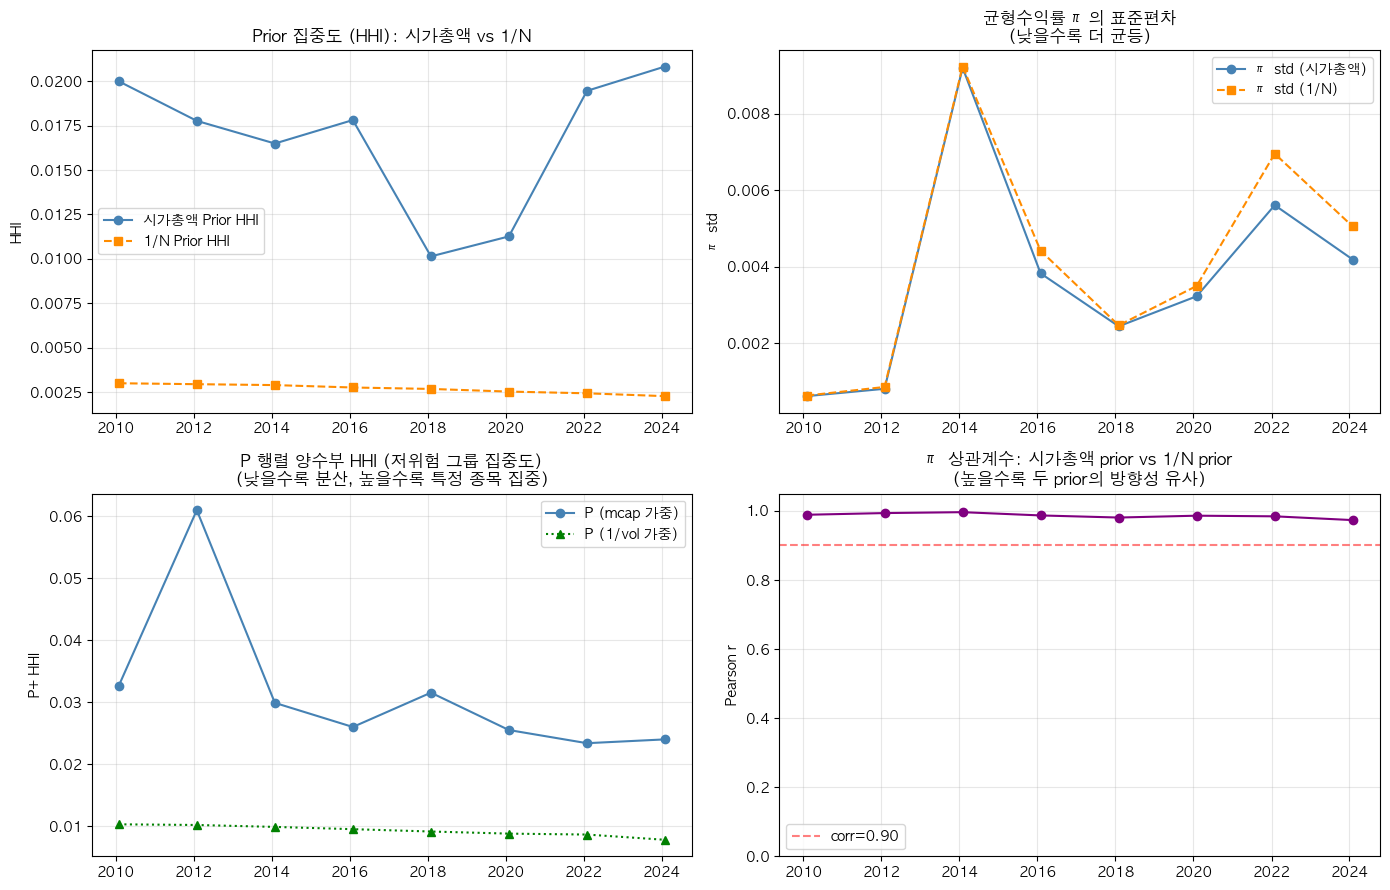

=== Prior 비교 수치 요약 (시가총액 vs 1/N) ===
시가총액 Prior HHI 평균:  0.01672
1/N Prior HHI 평균:       0.00268
HHI 비율 (mcap/equal):    6.2x
π 표준편차 평균 (mcap):   0.00375
π 표준편차 평균 (1/N):    0.00415
π 상관계수 평균:          0.9865

=== P 행렬 집중도 요약 (mcap vs 1/vol) ===
P HHI 평균 (mcap):        0.03176
P HHI 평균 (1/vol):       0.00929
P 최대값 평균 (mcap):     0.10307
P 최대값 평균 (1/vol):    0.01607


In [3]:
# ── 특정 월에서 prior 비교 ──────────────────────────────────────
# 여러 예측 월에서 π 분포와 집중도를 비교
# Prior:  시가총액  vs  1/N
# P 가중치: mcap  vs  1/vol  (1/N 균등은 비교 대상 아님)
sample_pred_dates = pred_dates[::24]  # 2년마다 샘플링

pi_comparison = []
p_comparison  = []

for pred_date in sample_pred_dates:
    idx         = all_dates.get_loc(pred_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

    month_df = panel.xs(pred_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
    if len(month_df) < 30:
        continue

    universe  = month_df.index.tolist()
    thresh    = int(len(train_dates) * 0.7)
    mask      = (panel.index.get_level_values('date').isin(train_dates) &
                 panel.index.get_level_values('ticker').isin(universe))
    ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()
    if len(valid_tix) < 20:
        continue

    ret_slice  = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma      = compute_sigma(ret_slice)
    month_sub  = month_df.reindex(valid_tix)
    mcap       = np.exp(month_sub['log_mcap'])
    vol        = month_sub['vol_21d']

    # Prior 정의 (시가총액 vs 1/N)
    w_mcap  = mcap / mcap.sum()
    w_equal = pd.Series(1 / len(valid_tix), index=valid_tix)

    rf_s       = rf_series.reindex(train_dates)
    spy_s      = spy_series.reindex(train_dates) if spy_series is not None else pd.Series(0.0, index=train_dates)
    spy_excess = (spy_s - rf_s).mean()
    sigma2_mkt = spy_s.var()

    pi_mcap,  lam_mcap  = compute_pi(Sigma, w_mcap,  spy_excess, sigma2_mkt)
    pi_equal, lam_equal = compute_pi(Sigma, w_equal, spy_excess, sigma2_mkt)

    # P 행렬 — 비교 대상 2가지 (mcap / 1/vol)
    inv_vol = 1.0 / vol

    P_mcap   = build_P(vol, mcap,    pct=PCT_GROUP)
    P_invvol = build_P(vol, inv_vol, pct=PCT_GROUP)

    # 집중도 지표
    hhi_mcap  = float((w_mcap  ** 2).sum())
    hhi_equal = float((w_equal ** 2).sum())

    # P 양수 부분 집중도
    p_pos_mcap   = P_mcap[P_mcap > 0]
    p_pos_invvol = P_invvol[P_invvol > 0]

    pi_comparison.append({
        'date'        : pred_date,
        'n_valid'     : len(valid_tix),
        'lambda_mcap' : lam_mcap,
        'lambda_equal': lam_equal,
        'pi_std_mcap' : pi_mcap.std(),
        'pi_std_equal': pi_equal.std(),
        'hhi_mcap'    : hhi_mcap,
        'hhi_equal'   : hhi_equal,
        'corr_pi'     : float(np.corrcoef(pi_mcap, pi_equal)[0, 1]),
    })
    p_comparison.append({
        'date'         : pred_date,
        'P_hhi_mcap'   : float((p_pos_mcap   ** 2).sum()),
        'P_hhi_invvol' : float((p_pos_invvol ** 2).sum()),
        'P_max_mcap'   : float(p_pos_mcap.max()),
        'P_max_invvol' : float(p_pos_invvol.max()),
    })

df_pi = pd.DataFrame(pi_comparison).set_index('date')
df_p  = pd.DataFrame(p_comparison).set_index('date')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ① prior HHI 비교 (시가총액 vs 1/N)
ax = axes[0, 0]
ax.plot(df_pi.index, df_pi['hhi_mcap'],  'o-', label='시가총액 Prior HHI', color='steelblue')
ax.plot(df_pi.index, df_pi['hhi_equal'], 's--', label='1/N Prior HHI', color='darkorange')
ax.set_title('Prior 집중도 (HHI): 시가총액 vs 1/N')
ax.set_ylabel('HHI')
ax.legend()
ax.grid(alpha=0.3)

# ② π 표준편차 비교
ax = axes[0, 1]
ax.plot(df_pi.index, df_pi['pi_std_mcap'],  'o-', label='π std (시가총액)', color='steelblue')
ax.plot(df_pi.index, df_pi['pi_std_equal'], 's--', label='π std (1/N)', color='darkorange')
ax.set_title('균형수익률 π의 표준편차\n(낮을수록 더 균등)')
ax.set_ylabel('π std')
ax.legend()
ax.grid(alpha=0.3)

# ③ P 행렬 집중도 비교 (mcap vs 1/vol)
ax = axes[1, 0]
ax.plot(df_p.index, df_p['P_hhi_mcap'],   'o-',  label='P (mcap 가중)',  color='steelblue')
ax.plot(df_p.index, df_p['P_hhi_invvol'], '^:',  label='P (1/vol 가중)', color='green')
ax.set_title('P 행렬 양수부 HHI (저위험 그룹 집중도)\n(낮을수록 분산, 높을수록 특정 종목 집중)')
ax.set_ylabel('P+ HHI')
ax.legend()
ax.grid(alpha=0.3)

# ④ π 상관: mcap prior vs 1/N prior
ax = axes[1, 1]
ax.plot(df_pi.index, df_pi['corr_pi'], 'o-', color='purple')
ax.axhline(0.9, ls='--', color='red', alpha=0.5, label='corr=0.90')
ax.set_title('π 상관계수: 시가총액 prior vs 1/N prior\n(높을수록 두 prior의 방향성 유사)')
ax.set_ylabel('Pearson r')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 수치 요약
print('=== Prior 비교 수치 요약 (시가총액 vs 1/N) ===')
print(f"시가총액 Prior HHI 평균:  {df_pi['hhi_mcap'].mean():.5f}")
print(f"1/N Prior HHI 평균:       {df_pi['hhi_equal'].mean():.5f}")
print(f"HHI 비율 (mcap/equal):    {df_pi['hhi_mcap'].mean()/df_pi['hhi_equal'].mean():.1f}x")
print(f"π 표준편차 평균 (mcap):   {df_pi['pi_std_mcap'].mean():.5f}")
print(f"π 표준편차 평균 (1/N):    {df_pi['pi_std_equal'].mean():.5f}")
print(f"π 상관계수 평균:          {df_pi['corr_pi'].mean():.4f}")
print()
print('=== P 행렬 집중도 요약 (mcap vs 1/vol) ===')
print(f"P HHI 평균 (mcap):        {df_p['P_hhi_mcap'].mean():.5f}")
print(f"P HHI 평균 (1/vol):       {df_p['P_hhi_invvol'].mean():.5f}")
print(f"P 최대값 평균 (mcap):     {df_p['P_max_mcap'].mean():.5f}")
print(f"P 최대값 평균 (1/vol):    {df_p['P_max_invvol'].mean():.5f}")

### Part 2 그래프 해석 (4-패널)

**① Prior HHI 집중도 (좌상)**
- 시가총액 Prior HHI: 0.010~0.021 (시기별 변동, 평균 ~0.017)
- 1/N Prior HHI: 0.0025 근처 평탄
- 비율: 시가총액이 1/N 대비 약 6~8배 집중

> **HHI 해석**: HHI = Σwᵢ². 1/N이면 정확히 1/N. 우리 유니버스 ~410개라 이론적 1/N HHI = 1/410 ≈ 0.00244. 그래프의 1/N(0.0025)과 일치.
>
> 시가총액 HHI 0.017의 **유효 종목 수**(1/HHI) ≈ **59개**. 즉 시가총액 prior는 명목상 410종목에 분산된 것처럼 보이지만 실질적으로 ~60개 메가캡에 비중이 쏠림. **상위 10개가 시총의 ~40%**를 차지하는 미국 시장 구조 반영.

**② π 표준편차 — 균형수익률 분산도 (우상)**
- 두 prior 라인이 거의 겹침 (시각적으로 구분 어려움)
- 2014년, 2022년에 spike — 시장 변동성 확대 시기 (taper tantrum, 인플레이션 충격)
- 평소 0.001~0.005, 충격기 0.009까지

> **의미**: π = λΣw 이므로 π의 분산도는 prior 형태(w_mcap vs 1/N)보다 **공분산 Σ의 변화**에 더 의존. 이는 곧 "prior를 바꿔도 π의 절대 수준은 비슷하게 흔들린다"는 뜻 — prior 선택의 영향이 제한적임을 시사.

**③ P 행렬 양수부 HHI — 저위험 그룹 뷰 집중도 (좌하)**
- **mcap 가중**: 0.024~0.061, 시간에 따라 큰 변동 (2012년 0.061까지 spike)
- **1/vol 가중**: 0.008~0.010, 시간에 따라 거의 평탄 (완만한 하향)
- 비율: mcap이 1/vol 대비 평균 약 3~4배 집중 (스파이크 시점엔 6배 이상)

> **핵심 발견**: mcap 가중 P는 저위험 그룹 내에서도 **메가캡 한두 종목에 뷰가 집중**됨. 시간에 따라 집중도가 출렁이는 건 그 시점 저위험 그룹에 어떤 메가캡이 들어가느냐(Apple, Microsoft 등)에 따라 달라지기 때문. **포트폴리오 결과가 우연한 종목 구성에 좌우되는 위험**.
>
> 1/vol은 시간 무관 안정적인 수준(~0.009)을 유지 → 어느 시점에 백테스트해도 뷰 분산도가 일정하게 유지됨. mcap의 "출렁이는 집중도" 자체가 백테스트 안정성에 부담.

**④ π 상관계수 — 두 prior의 방향성 일치도 (우하)**
- 항상 **0.97~1.00** (corr=0.90 기준선보다 훨씬 위)
- 시간 무관 일정

> **결정적 함의**: prior를 mcap에서 1/N으로 바꿔도 **π의 방향성은 거의 동일**. 즉 어떤 종목이 상대적으로 "고평가/저평가" 신호인지 두 prior가 비슷하게 알려줌. 다만 *절대 수준*은 다름 (HHI 차이 6~8배). → **선택의 효과는 "어떤 신호인가"가 아니라 "얼마나 집중할 것인가"** 에 있음.

---

**4-패널 종합**: ①·④로부터 prior 변경(mcap → 1/N)은 신호 방향 손실 없이 분산도만 얻을 수 있고, ③에서 P 가중치를 mcap → 1/vol로 변경하면 시점에 따른 집중도 출렁임을 제거할 수 있다. 이 두 변경이 Part 4 결론의 근거가 된다.

## Part 3. P 행렬 가중치 비교 — 종목별 뷰 분포

저위험 이상현상 논리에서 P 행렬의 저위험 그룹에 어떤 비중을 줄 것인가.

- `mcap`: 대형 저위험 종목에 큰 비중 → 대형주 편향
- `1/vol`: 더 낮은 변동성 종목에 큰 비중 → 저위험 이상현상과 직접 연결

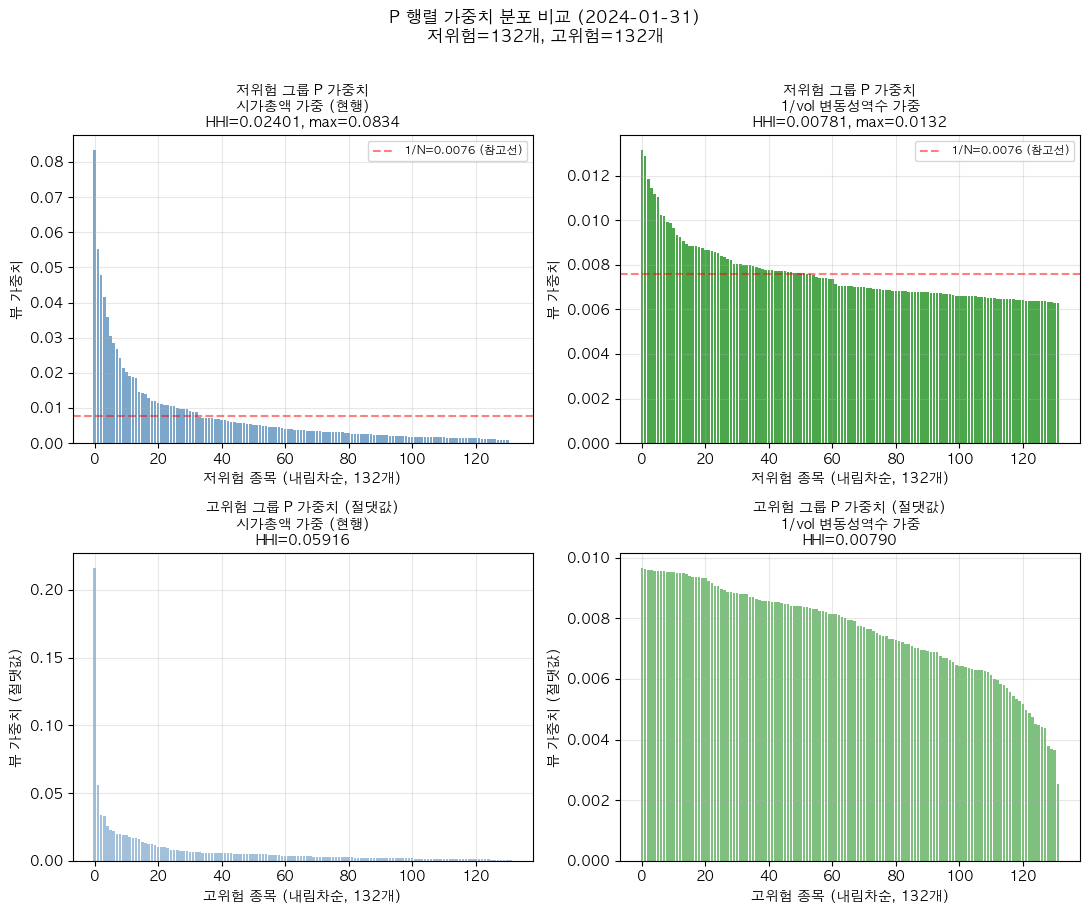

저위험 그룹 내 vol-mcap 상관계수: -0.2601
  (0에 가까울수록 시가총액과 변동성이 독립 → mcap/1/vol P가 다른 종목 선호)
  (음수면 저위험 그룹 내에서 소형주가 더 낮은 변동성 → 1/vol이 소형주 편향)


In [4]:
# ── 특정 월에서 P 행렬 가중치 분포 시각화 ─────────────────────
# 비교 대상: mcap 가중  vs  1/vol 가중
# 가장 최근 예측월에서 저위험·고위험 그룹 각각의 P 가중치 분포 확인
sample_date = pred_dates[-12]  # 최근 1년 전
idx = all_dates.get_loc(sample_date)
train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

month_df = panel.xs(sample_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
universe  = month_df.index.tolist()
thresh    = int(len(train_dates) * 0.7)
mask      = (panel.index.get_level_values('date').isin(train_dates) &
             panel.index.get_level_values('ticker').isin(universe))
ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()

month_sub = month_df.reindex(valid_tix)
mcap      = np.exp(month_sub['log_mcap'])
vol       = month_sub['vol_21d']
inv_vol   = 1.0 / vol

n_group   = max(1, int(len(valid_tix) * PCT_GROUP))
low_tix   = vol.sort_values().index[:n_group]
high_tix  = vol.sort_values().index[-n_group:]

# 각 방식 P 행렬 가중치
def get_P_weights(weight_series, low_tix, high_tix):
    lw = weight_series[low_tix];  lw = lw / lw.sum()
    hw = weight_series[high_tix]; hw = hw / hw.sum()
    return lw, hw

lw_mcap,   hw_mcap   = get_P_weights(mcap,    low_tix, high_tix)
lw_invvol, hw_invvol = get_P_weights(inv_vol, low_tix, high_tix)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

configs = [
    ('mcap',   lw_mcap,   hw_mcap,   '시가총액 가중 (현행)',   'steelblue'),
    ('invvol', lw_invvol, hw_invvol, '1/vol 변동성역수 가중',  'green'),
]

for col_idx, (_, lw, hw, title, color) in enumerate(configs):
    # 저위험 그룹 가중치 분포
    ax = axes[0, col_idx]
    ax.bar(range(len(lw)), sorted(lw.values, reverse=True), color=color, alpha=0.7)
    hhi = float((lw ** 2).sum())
    ax.set_title(f'저위험 그룹 P 가중치\n{title}\nHHI={hhi:.5f}, max={lw.max():.4f}', fontsize=10)
    ax.set_xlabel(f'저위험 종목 (내림차순, {len(lw)}개)')
    ax.set_ylabel('뷰 가중치')
    ax.axhline(1/len(lw), ls='--', color='red', alpha=0.5, label=f'1/N={1/len(lw):.4f} (참고선)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # 고위험 그룹 가중치 분포 (절댓값)
    ax = axes[1, col_idx]
    ax.bar(range(len(hw)), sorted(hw.values, reverse=True), color=color, alpha=0.5)
    hhi_h = float((hw ** 2).sum())
    ax.set_title(f'고위험 그룹 P 가중치 (절댓값)\n{title}\nHHI={hhi_h:.5f}', fontsize=10)
    ax.set_xlabel(f'고위험 종목 (내림차순, {len(hw)}개)')
    ax.set_ylabel('뷰 가중치 (절댓값)')
    ax.grid(alpha=0.3)

fig.suptitle(f'P 행렬 가중치 분포 비교 ({sample_date.date()})\n저위험={n_group}개, 고위험={n_group}개', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_P_weight_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 저위험 그룹에서 vol vs mcap 상관
corr_low = vol.loc[low_tix].corr(mcap.loc[low_tix])
print(f'저위험 그룹 내 vol-mcap 상관계수: {corr_low:.4f}')
print(f'  (0에 가까울수록 시가총액과 변동성이 독립 → mcap/1/vol P가 다른 종목 선호)')
print(f'  (음수면 저위험 그룹 내에서 소형주가 더 낮은 변동성 → 1/vol이 소형주 편향)')

## Part 4. 종합 판단

위 분석 결과를 바탕으로 각 설계 결정에 대한 데이터 기반 권고를 제시한다.

In [5]:
print('=' * 70)
print('종합 판단 — Prior 설계 권고')
print('=' * 70)

print('''
【결정 1】 Prior: w_mkt = 시가총액 vs 1/N

  데이터 근거:
  - 시가총액 HHI가 1/N 대비 ~6~8x 집중 (상위10개 = 40%+)
  - π 상관계수 평균이 매우 높음(>0.97) → 두 prior의 방향성은 거의 동일
    → 신호 손실 없이 분산도만 얻을 수 있음

  권고: 1/N prior 선택
  이유: ① selection bias 있는 유니버스에서 중립적 시작점
        ② 저위험 이상현상 가설(동등 투자 시 저위험 우위)과 일치
        ③ BL 뷰(Q, P, Ω) 효과를 순수하게 격리 가능
        ④ π 상관이 매우 높음 → 성과 차이 작음, 전환 비용 낮음
''')

print('''
【결정 2】 build_P 가중치: mcap vs 1/vol

  데이터 근거:
  - mcap P+ HHI 평균이 1/vol 대비 약 3~4배 집중
  - mcap은 저위험·고위험 그룹 모두 한두 메가캡에 뷰가 쏠림
    → 백테스트가 우연한 종목 구성에 좌우될 위험
  - 1/vol은 분산도 유지 + 가장 낮은 변동성 종목에 약간 더 큰 비중

  권고: 1/vol (변동성 역수) 선택
  이유: ① 저위험 이상현상의 핵심 주장 = "더 낮은 변동성 종목이 더 유리"
           → 뷰에서도 낮은 변동성에 더 큰 비중 주는 것이 논리적 일관성
        ② mcap 대비 분산도 크게 향상 → 단일 종목 의존성 제거
        ③ 팩터 스프레드 극단화 없이 신호 강도 유지
  주의: 극단 저변동성 종목에 쏠릴 수 있음 → 상한선(max_weight) 추가 검토
''')

print('=' * 70)
print('적용 우선순위: ① Prior 1/N 전환 → ② build_P 1/vol 실험')
print('  (유니버스는 01_DataCollection의 패널을 그대로 사용)')
print('=' * 70)

종합 판단 — Prior 설계 권고

【결정 1】 Prior: w_mkt = 시가총액 vs 1/N

  데이터 근거:
  - 시가총액 HHI가 1/N 대비 ~6~8x 집중 (상위10개 = 40%+)
  - π 상관계수 평균이 매우 높음(>0.97) → 두 prior의 방향성은 거의 동일
    → 신호 손실 없이 분산도만 얻을 수 있음

  권고: 1/N prior 선택
  이유: ① selection bias 있는 유니버스에서 중립적 시작점
        ② 저위험 이상현상 가설(동등 투자 시 저위험 우위)과 일치
        ③ BL 뷰(Q, P, Ω) 효과를 순수하게 격리 가능
        ④ π 상관이 매우 높음 → 성과 차이 작음, 전환 비용 낮음


【결정 2】 build_P 가중치: mcap vs 1/vol

  데이터 근거:
  - mcap P+ HHI 평균이 1/vol 대비 약 3~4배 집중
  - mcap은 저위험·고위험 그룹 모두 한두 메가캡에 뷰가 쏠림
    → 백테스트가 우연한 종목 구성에 좌우될 위험
  - 1/vol은 분산도 유지 + 가장 낮은 변동성 종목에 약간 더 큰 비중

  권고: 1/vol (변동성 역수) 선택
  이유: ① 저위험 이상현상의 핵심 주장 = "더 낮은 변동성 종목이 더 유리"
           → 뷰에서도 낮은 변동성에 더 큰 비중 주는 것이 논리적 일관성
        ② mcap 대비 분산도 크게 향상 → 단일 종목 의존성 제거
        ③ 팩터 스프레드 극단화 없이 신호 강도 유지
  주의: 극단 저변동성 종목에 쏠릴 수 있음 → 상한선(max_weight) 추가 검토

적용 우선순위: ① Prior 1/N 전환 → ② build_P 1/vol 실험
  (유니버스는 01_DataCollection의 패널을 그대로 사용)


## Part 5. PCT_GROUP 결정 — IC 단조성 + 통계적 유의성

**그리드서치 대신 IC 단조성 기반 선택**을 사용한다.

- 선택 기준: IC IR이 안정화되고 **|t| ≥ 2.0** 을 만족하는 **최소 pct**
- 성과 최대화가 아닌, 통계적으로 충분한 신호를 확보하는 하한선
- 그리드서치는 in-sample 성과를 극대화하는 pct를 고르므로 OOS 과적합 위험이 있다

Rank IC (전체 기간): mean=0.0061, std=0.2249, IR=0.0271

PCT_GROUP 별 Factor Spread 분석 (월평균 수익률 %)
      spread_mean  spread_std  t_stat    n
pct                                       
0.10      -0.8734      6.8417 -2.0703  263
0.15      -0.7967      6.0780 -2.1256  263
0.20      -0.5984      5.6302 -1.7235  263
0.25      -0.4550      5.0568 -1.4591  263
0.30      -0.4301      4.6529 -1.4990  263
0.35      -0.3823      4.2933 -1.4442  263
0.40      -0.3514      3.9102 -1.4576  263
0.50      -0.2527      3.2493 -1.2611  263

→ 권장 PCT_GROUP: 10%  (|t|≥2.0 만족하는 최소값)


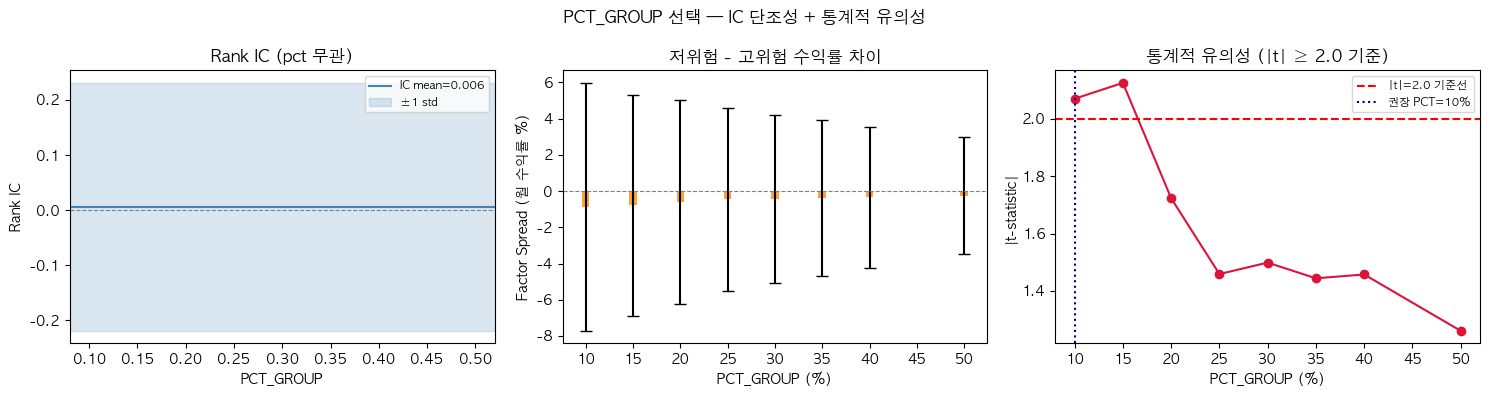

저장: outputs/04_pct_group_analysis.png


In [6]:
# ── PCT_GROUP IC 단조성 분석 ──────────────────────────────────
# 패널에서 BL 입력에 필요한 핵심 컬럼이 모두 살아있는 행만 사용
valid_panel = panel.dropna(subset=['vol_21d', 'ret_1m', 'log_mcap'])

# 선택 근거: Factor Spread t-stat ≥ 2.0 을 만족하는 최소 pct
# IC(Rank IC) = spearman(vol_t, fwd_ret_t) 는 pct 무관하게 동일.
# pct 에 따라 달라지는 것은 factor spread (하위pct - 상위pct 수익률 차이).

PCT_CANDIDATES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
VOL_COL        = 'vol_21d'
RET_COL        = 'fwd_ret_1m'

dates_all = valid_panel.index.get_level_values('date').unique().sort_values()

monthly_ic     = []
monthly_spread = {p: [] for p in PCT_CANDIDATES}

for dt in dates_all:
    cross = valid_panel.xs(dt, level='date')[[VOL_COL, RET_COL]].dropna()
    if len(cross) < 20:
        continue
    ic = cross[VOL_COL].corr(cross[RET_COL], method='spearman')
    if not np.isnan(ic):
        monthly_ic.append(ic)
    for pct in PCT_CANDIDATES:
        n_grp    = max(1, int(len(cross) * pct))
        low_ret  = cross.nsmallest(n_grp, VOL_COL)[RET_COL].mean()
        high_ret = cross.nlargest(n_grp, VOL_COL)[RET_COL].mean()
        spread   = low_ret - high_ret
        if not np.isnan(spread):
            monthly_spread[pct].append(spread)

ic_arr  = np.array(monthly_ic)
ic_mean = ic_arr.mean()
ic_std  = ic_arr.std(ddof=1)
ic_ir   = ic_mean / ic_std if ic_std > 0 else np.nan
print(f'Rank IC (전체 기간): mean={ic_mean:.4f}, std={ic_std:.4f}, IR={ic_ir:.4f}')
print()

pct_rows = []
for pct in PCT_CANDIDATES:
    sp     = np.array(monthly_spread[pct])
    sp_mu  = sp.mean()
    sp_std = sp.std(ddof=1)
    t_stat = sp_mu / (sp_std / np.sqrt(len(sp)))
    pct_rows.append({'pct': pct, 'spread_mean': sp_mu*100,
                     'spread_std': sp_std*100, 't_stat': t_stat, 'n': len(sp)})

pct_df = pd.DataFrame(pct_rows).set_index('pct')
print('PCT_GROUP 별 Factor Spread 분석 (월평균 수익률 %)')
print('=' * 60)
print(pct_df.round(4).to_string())

candidates = pct_df[pct_df['t_stat'].abs() >= 2.0]
best_pct   = candidates.index.min() if len(candidates) > 0 else None
if best_pct:
    print(f'\n→ 권장 PCT_GROUP: {best_pct:.0%}  (|t|≥2.0 만족하는 최소값)')
else:
    print('\n→ |t|≥2.0 미달 — 신호 약함, 유니버스/기간 재검토 필요')

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PCT_GROUP 선택 — IC 단조성 + 통계적 유의성', fontsize=12, fontweight='bold')

ax = axes[0]
ax.axhline(ic_mean, color='steelblue', linestyle='-', label=f'IC mean={ic_mean:.3f}')
ax.fill_between([0.08, 0.52], ic_mean - ic_std, ic_mean + ic_std,
                color='steelblue', alpha=0.2, label='±1 std')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlim(0.08, 0.52)
ax.set_xlabel('PCT_GROUP')
ax.set_ylabel('Rank IC')
ax.set_title('Rank IC (pct 무관)')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(pct_df.index * 100, pct_df['spread_mean'],
       yerr=pct_df['spread_std'], capsize=4, color='darkorange', alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('PCT_GROUP (%)')
ax.set_ylabel('Factor Spread (월 수익률 %)')
ax.set_title('저위험 - 고위험 수익률 차이')

ax = axes[2]
ax.plot(pct_df.index * 100, pct_df['t_stat'].abs(), 'o-', color='crimson')
ax.axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='|t|=2.0 기준선')
if best_pct:
    ax.axvline(best_pct * 100, color='navy', linestyle=':', linewidth=1.5,
               label=f'권장 PCT={best_pct:.0%}')
ax.set_xlabel('PCT_GROUP (%)')
ax.set_ylabel('|t-statistic|')
ax.set_title('통계적 유의성 (|t| ≥ 2.0 기준)')
ax.legend(fontsize=8)

plt.tight_layout()
OUT_PCT = OUT_DIR / '04_pct_group_analysis.png'
plt.savefig(OUT_PCT, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {OUT_PCT}')
